In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import pandas as pd
import numpy as np


In [3]:
parquet_path = "/content/drive/MyDrive/Dashboard-BR-CA-Data/exports_all.parquet"

dataset = pd.read_parquet(parquet_path)

print(dataset.shape)
dataset.head()

(2562365, 9)


,Period,Commodity,Province,Country,State,Value ($),Quantity,Unit of measure,source_file
0,2024-07-01,9901.00.00 - Low value export transactions and...,Northwest Territories,United States,Unknown states,4296.0,0.0,Blank,01-Exports_NT_2024_Jan-Dec.csv
1,2024-11-01,"7102.39.00 - Diamonds, non-industrial, sorted,...",Northwest Territories,United States,New York,53604.0,85.0,Weight in carats,01-Exports_NT_2024_Jan-Dec.csv
2,2024-01-01,"7102.10.00 - Diamonds, unsorted",Northwest Territories,Botswana,None,36869729.0,353535.0,Weight in carats,01-Exports_NT_2024_Jan-Dec.csv
3,2024-12-01,8526.92.00 - Radio remote control apparatus,Northwest Territories,United States,Colorado,11130.0,0.0,Blank,01-Exports_NT_2024_Jan-Dec.csv
4,2024-05-01,"8807.30.00 - Parts, nes, of aeroplanes, helico...",Northwest Territories,United Kingdom,None,2734.0,0.0,Blank,01-Exports_NT_2024_Jan-Dec.csv


In [4]:
#dataset.isna().sum()

In [5]:
#Remove space and special characters in column names
dataset.columns = dataset.columns.str.strip()

# Check data types
print(dataset.dtypes)


Period             datetime64[ns]
Commodity                  object
Province                   object
Country                    object
State                      object
Value ($)                 float64
Quantity                  float64
Unit of measure            object
source_file                object
dtype: object


In [6]:
#Period to datetime
dataset['Period'] = pd.to_datetime(dataset['Period'], errors='coerce')
#print(dataset['Period'].head())
#print(dataset.dtypes)

In [7]:
# Grouped by commodity - checking statistics of Value($) and quantity
pd.options.display.float_format = '{:,.1f}'.format

summary = dataset.groupby('Commodity').agg(
    total_value=('Value ($)', 'sum'),
    mean_value=('Value ($)', 'mean'),
    std_value=('Value ($)', 'std'),
    min_value=('Value ($)', 'min'),
    max_value=('Value ($)', 'max'),

    total_quantity=('Quantity', 'sum'),
    mean_quantity=('Quantity', 'mean'),
    std_quantity=('Quantity', 'std'),
    min_quantity=('Quantity', 'min'),
    max_quantity=('Quantity', 'max')
).reset_index()

summary['Commodity'] = summary['Commodity'].apply(lambda x: x.split(' - ')[0])
print(summary)

       Commodity     total_value  mean_value    std_value  min_value  \
0     0101.21.00     8,697,163.0    41,024.4     51,666.9    3,039.0   
1     0101.29.10    47,229,477.0 1,574,315.9    913,952.6  500,879.0   
2     0101.29.90   115,622,915.0    76,979.3    176,013.6    2,500.0   
3     0101.30.00       124,624.0    11,329.5      4,356.8    5,591.0   
4     0101.90.00         3,079.0     3,079.0          NaN    3,079.0   
...          ...             ...         ...          ...        ...   
5747  9811.00.10            41.0        41.0          NaN       41.0   
5748  9811.00.20         7,331.0     7,331.0          NaN    7,331.0   
5749  9811.00.58         2,328.0     2,328.0          NaN    2,328.0   
5750  9812.00.00       405,168.0    11,916.7     66,146.7        1.0   
5751  9901.00.00 9,966,710,496.0 3,434,428.2 18,263,869.0        1.0   

         max_value  total_quantity  mean_quantity  std_quantity  min_quantity  \
0        346,138.0         1,290.0            6.1     

In [8]:
# Ensure it's a string
dataset['Commodity'] = dataset['Commodity'].astype(str)

# Extract HS8: pattern is XXXX.XX.XX
dataset['HS8'] = dataset['Commodity'].str.extract(r'^(\d{4}\.\d{2}\.\d{2})')[0]
dataset['HS8'] = dataset['HS8'].str.replace('.', '', regex=False)  # → 8-digit string e.g. "99010000"

# HS6 is first 6 digits of HS8
dataset['HS6'] = dataset['HS8'].str[:6]  # → "990100"

print(dataset[['Commodity', 'HS8', 'HS6']])

                                                 Commodity       HS8     HS6
0        9901.00.00 - Low value export transactions and...  99010000  990100
1        7102.39.00 - Diamonds, non-industrial, sorted,...  71023900  710239
2                          7102.10.00 - Diamonds, unsorted  71021000  710210
3              8526.92.00 - Radio remote control apparatus  85269200  852692
4        8807.30.00 - Parts, nes, of aeroplanes, helico...  88073000  880730
...                                                    ...       ...     ...
2562360  8903.99.90 - Rowing boats,canoes,etc,o/t inflt...  89039990  890399
2562361  9027.50.00 - Instruments and apparatus, using ...  90275000  902750
2562362  9207.90.00 - Musical instruments nes, sound ge...  92079000  920790
2562363  9306.90.00 - Munitions of war & pts thereof & ...  93069000  930690
2562364                9403.60.00 - Furniture, wooden, nes  94036000  940360

[2562365 rows x 3 columns]


In [9]:
# Aggregate by HS6
hs6_summary = dataset.groupby('HS6')[['Value ($)', 'Quantity']].sum().reset_index()

# Aggregate by HS8
hs8_summary = dataset.groupby('HS8')[['Value ($)', 'Quantity']].sum().reset_index()

**How many unique codes (HS6 and HS8)**

In [10]:
#   unique HS6
num_HS6 = dataset['HS6'].nunique()
print(f"Number of unique HS6 codes: {num_HS6}")

# unique HS8
num_HS8 = dataset['HS8'].nunique()
print(f"Number of unique HS8 codes: {num_HS8}")

Number of unique HS6 codes: 5177
Number of unique HS8 codes: 5751


**How many records are in each HS6 and HS8?**

In [11]:
# Define bins and labels
bins = [0, 10, 30, 100, float('inf')]
labels = ['1-10', '11-30', '31-100', '100+']

#  HS6 counts
hs6_counts = dataset.groupby('HS6').size().reset_index(name='element_count')
hs6_counts = hs6_counts.sort_values(by='element_count', ascending=True)

hs6_counts['size_category'] = pd.cut(hs6_counts['element_count'], bins=bins, labels=labels, right=True)

# HS6 percentages
hs6_summary = (hs6_counts['size_category'].value_counts(normalize=True).sort_index() * 100).round(1)


# HS8 counts
hs8_counts = dataset.groupby('HS8').size().reset_index(name='element_count')
hs8_counts = hs8_counts.sort_values(by='element_count', ascending=True)

hs8_counts['size_category'] = pd.cut(hs8_counts['element_count'], bins=bins, labels=labels, right=True)

# HS8 percentages
hs8_summary = (hs8_counts['size_category'].value_counts(normalize=True).sort_index() * 100).round(1)

print("HS6 group size percentages:")
print(hs6_summary)

print("\nHS8 group size percentages:")
print(hs8_summary)

HS6 group size percentages:
size_category
1-10     17.8
11-30    12.4
31-100   17.6
100+     52.2
Name: proportion, dtype: float64

HS8 group size percentages:
size_category
1-10     17.6
11-30    12.4
31-100   17.9
100+     52.0
Name: proportion, dtype: float64


In [12]:
# Minimun acceptable number of rows
HS8_MIN = 30
HS6_MIN = 30

sparse_hs8 = hs8_counts[hs8_counts['element_count'] < HS8_MIN]['HS8'].tolist() # All HS8 code w/ less 30 records

#Taking the sparse_Hs8 rows found, if we zoom out to HS6, how many rows do we have?
rescued = dataset[dataset['HS8'].isin(sparse_hs8)].groupby('HS6').size().reset_index(name='hs6_count')
rescued['rescued'] = rescued['hs6_count'] >= HS6_MIN # if it has more than 30 rows now, flag it.

print(f"Sparse HS8 codes (< {HS8_MIN} rows): {len(sparse_hs8)}")
print(f"Of those, HS6 groups with enough data: {rescued['rescued'].sum()}")
print(f"Still too sparse even at HS6: {(~rescued['rescued']).sum()}")

Sparse HS8 codes (< 30 rows): 1706
Of those, HS6 groups with enough data: 19
Still too sparse even at HS6: 1618


**HS8**

In [27]:
# commodity code (remove ".")
commodity_code = '84212100'

df_comm = dataset[dataset['HS8'] == commodity_code]

print(f"Number of rows for commodity {commodity_code}: {len(df_comm)}")

# Show summary stats
print(df_comm[['Value ($)', 'Quantity']].describe())


Number of rows for commodity 84212100: 3717
         Value ($)    Quantity
count      3,717.0     3,717.0
mean     360,646.6    15,768.4
std    1,250,830.6   157,237.6
min           12.0         1.0
25%       10,590.0         3.0
50%       40,212.0        18.0
75%      170,478.0       107.0
max   17,890,222.0 3,886,148.0


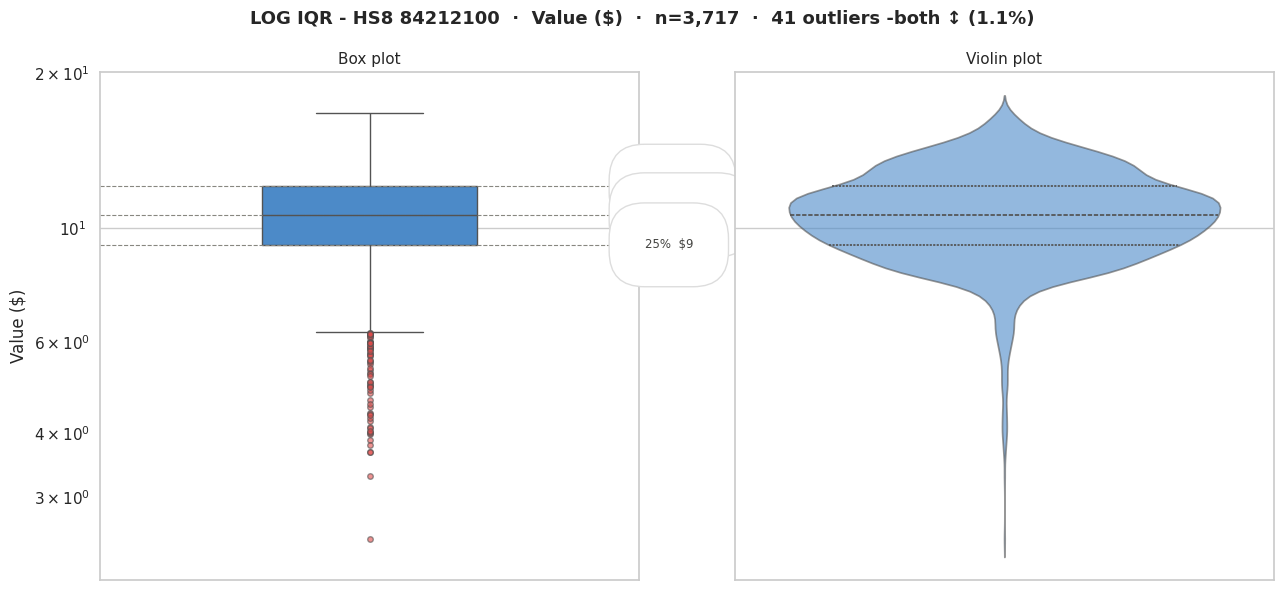

Outliers (> hi_fence): 13
Outliers (< lo_fence): 28
hi_fence: $16
lo_fence: $5


In [28]:
df_comm = dataset[dataset['HS8'] == commodity_code]['Value ($)'].dropna()
df_comm = df_comm[df_comm > 0]

df_comm = np.log(df_comm) # log

# ── stats ──────────────────────────────────────────────────────────────────
n      = len(df_comm) # observations

# Quartis and Median
median = df_comm.median()
p25    = df_comm.quantile(0.25)
p75    = df_comm.quantile(0.75)


iqr    = p75 - p25
lo_fence = p25 - 1.5 * iqr
hi_fence = p75 + 1.5 * iqr
n_out_low  = (df_comm < lo_fence).sum()
n_out_high = (df_comm > hi_fence).sum()
n_out      = n_out_low + n_out_high

def fmt(v):
    if v >= 1e6: return f'${v/1e6:.1f}M'
    if v >= 1e3: return f'${v/1e3:.0f}K'
    return f'${v:,.0f}'

# direção dos outliers
if n_out_low > 0 and n_out_high == 0:
    out_dir = 'outliers ↓'
elif n_out_high > 0 and n_out_low == 0:
    out_dir = 'outliers ↑'
else:
    out_dir = 'outliers -both ↕'

# ── figure ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
fig.suptitle(
    f'LOG IQR - HS8 {commodity_code}  ·  Value ($)  ·  n={n:,}  ·  '
    f'{n_out} {out_dir} ({n_out/n*100:.1f}%)',
    fontsize=13, fontweight='bold'
)

for ax in (ax1, ax2):
    ax.set_yscale('log')

# box plot
sns.boxplot(y=df_comm, ax=ax1, color='#378ADD', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='#E24B4A', markersize=4, alpha=0.6))
ax1.set_title('Box plot', fontsize=11)

# anotations
for label, val in [('75%', p75), ('Median', median), ('25%', p25)]:
    ax1.axhline(val, color='#888780', linewidth=0.8, linestyle='--')
    ax1.annotate(
        f'{label}  {fmt(val)}',
        xy=(1.01, val),
        xycoords=('axes fraction', 'data'),
        fontsize=8.5,
        color='#444441',
        va='center',
        bbox=dict(facecolor='white', edgecolor='#ddd', pad=3, boxstyle='round')
    )

# violin plot
sns.violinplot(y=df_comm, ax=ax2, color='#378ADD', alpha=0.6, inner='quartile')
ax2.set_title('Violin plot', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Outliers (> hi_fence): {n_out_high}")
print(f"Outliers (< lo_fence): {n_out_low}")
print(f"hi_fence: {fmt(hi_fence)}")
print(f"lo_fence: {fmt(lo_fence)}")

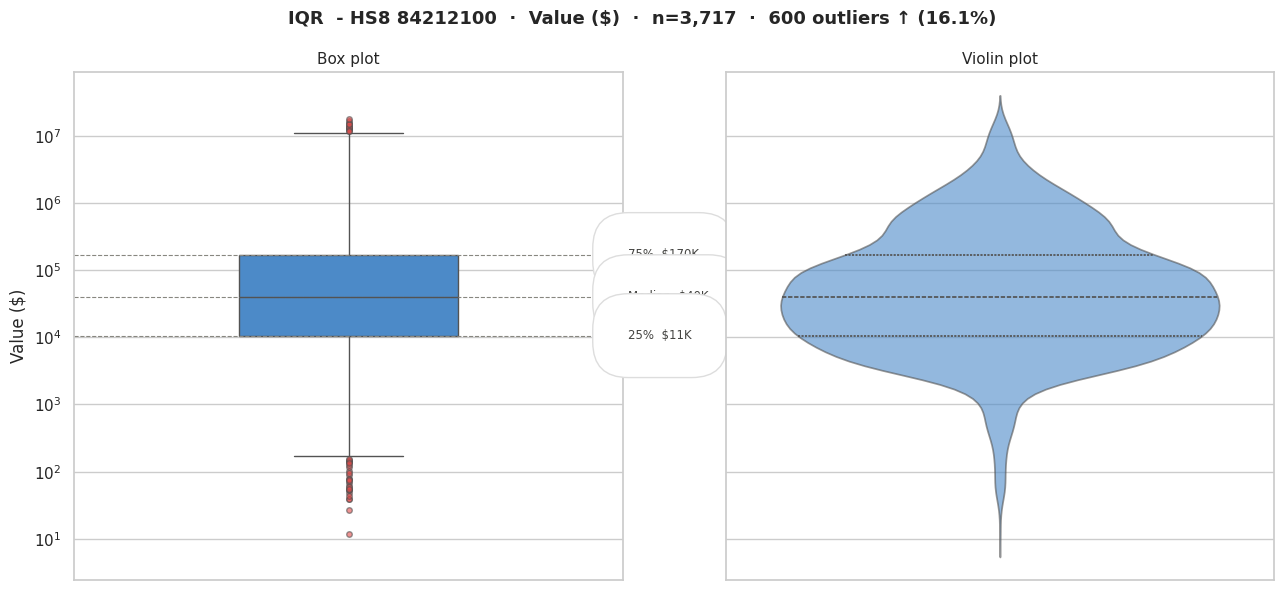

Outliers (> hi_fence): 600
Outliers (< lo_fence): 0
hi_fence: $410K
lo_fence: $-229,242


In [29]:
df_comm = dataset[dataset['HS8'] == commodity_code]['Value ($)'].dropna()
df_comm = df_comm[df_comm > 0]

# ── stats ──────────────────────────────────────────────────────────────────
n      = len(df_comm) # observations

# Quartis and Median
median = df_comm.median()
p25    = df_comm.quantile(0.25)
p75    = df_comm.quantile(0.75)


iqr    = p75 - p25
lo_fence = p25 - 1.5 * iqr
hi_fence = p75 + 1.5 * iqr
n_out_low  = (df_comm < lo_fence).sum()
n_out_high = (df_comm > hi_fence).sum()
n_out      = n_out_low + n_out_high

def fmt(v):
    if v >= 1e6: return f'${v/1e6:.1f}M'
    if v >= 1e3: return f'${v/1e3:.0f}K'
    return f'${v:,.0f}'

# direção dos outliers
if n_out_low > 0 and n_out_high == 0:
    out_dir = 'outliers ↓'
elif n_out_high > 0 and n_out_low == 0:
    out_dir = 'outliers ↑'
else:
    out_dir = 'outliers -both ↕'

# ── figure ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
fig.suptitle(
    f'IQR  - HS8 {commodity_code}  ·  Value ($)  ·  n={n:,}  ·  '
    f'{n_out} {out_dir} ({n_out/n*100:.1f}%)',
    fontsize=13, fontweight='bold'
)

for ax in (ax1, ax2):
    ax.set_yscale('log')

# box plot
sns.boxplot(y=df_comm, ax=ax1, color='#378ADD', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='#E24B4A', markersize=4, alpha=0.6))
ax1.set_title('Box plot', fontsize=11)

# anotations
for label, val in [('75%', p75), ('Median', median), ('25%', p25)]:
    ax1.axhline(val, color='#888780', linewidth=0.8, linestyle='--')
    ax1.annotate(
        f'{label}  {fmt(val)}',
        xy=(1.01, val),
        xycoords=('axes fraction', 'data'),
        fontsize=8.5,
        color='#444441',
        va='center',
        bbox=dict(facecolor='white', edgecolor='#ddd', pad=3, boxstyle='round')
    )

# violin plot
sns.violinplot(y=df_comm, ax=ax2, color='#378ADD', alpha=0.6, inner='quartile')
ax2.set_title('Violin plot', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Outliers (> hi_fence): {n_out_high}")
print(f"Outliers (< lo_fence): {n_out_low}")
print(f"hi_fence: {fmt(hi_fence)}")
print(f"lo_fence: {fmt(lo_fence)}")

**HS6**

In [31]:
# commodity code (remove ".")
commodity_code = '842121'

df_comm = dataset[dataset['HS6'] == commodity_code]

print(f"Number of rows for commodity {commodity_code}: {len(df_comm)}")

# Show summary stats
print(df_comm[['Value ($)', 'Quantity']].describe())


Number of rows for commodity 842121: 3717
         Value ($)    Quantity
count      3,717.0     3,717.0
mean     360,646.6    15,768.4
std    1,250,830.6   157,237.6
min           12.0         1.0
25%       10,590.0         3.0
50%       40,212.0        18.0
75%      170,478.0       107.0
max   17,890,222.0 3,886,148.0


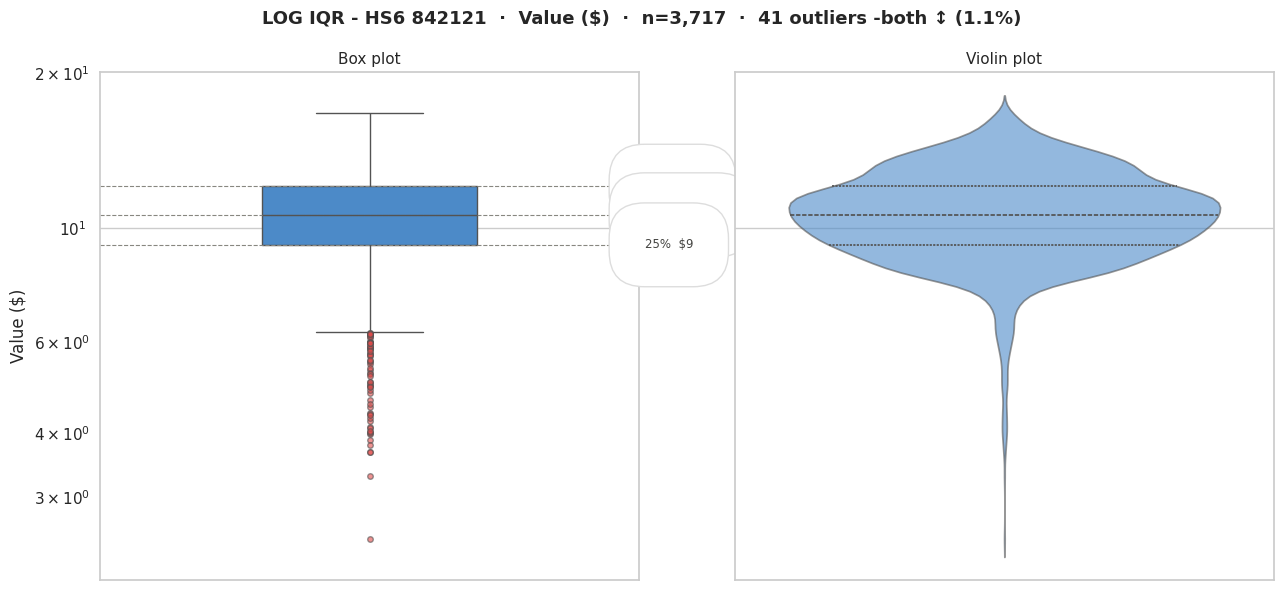

Outliers (> hi_fence): 13
Outliers(< lo_fence): 28
hi_fence: $16
lo_fence: $5


In [32]:
df_comm = dataset[dataset['HS6'] == commodity_code]['Value ($)'].dropna()
df_comm = df_comm[df_comm > 0]

df_comm = np.log(df_comm) # log

# ── stats ──────────────────────────────────────────────────────────────────
n      = len(df_comm) # observations

# Quartis and Median
median = df_comm.median()
p25    = df_comm.quantile(0.25)
p75    = df_comm.quantile(0.75)


iqr    = p75 - p25
lo_fence = p25 - 1.5 * iqr
hi_fence = p75 + 1.5 * iqr
n_out_low  = (df_comm < lo_fence).sum()
n_out_high = (df_comm > hi_fence).sum()
n_out      = n_out_low + n_out_high

def fmt(v):
    if v >= 1e6: return f'${v/1e6:.1f}M'
    if v >= 1e3: return f'${v/1e3:.0f}K'
    return f'${v:,.0f}'

# direção dos outliers
if n_out_low > 0 and n_out_high == 0:
    out_dir = 'outliers ↓'
elif n_out_high > 0 and n_out_low == 0:
    out_dir = 'outliers ↑'
else:
    out_dir = 'outliers -both ↕'

# ── figure ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
fig.suptitle(
    f'LOG IQR - HS6 {commodity_code}  ·  Value ($)  ·  n={n:,}  ·  '
    f'{n_out} {out_dir} ({n_out/n*100:.1f}%)',
    fontsize=13, fontweight='bold'
)

for ax in (ax1, ax2):
    ax.set_yscale('log')

# box plot
sns.boxplot(y=df_comm, ax=ax1, color='#378ADD', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='#E24B4A', markersize=4, alpha=0.6))
ax1.set_title('Box plot', fontsize=11)

# anotations
for label, val in [('75%', p75), ('Median', median), ('25%', p25)]:
    ax1.axhline(val, color='#888780', linewidth=0.8, linestyle='--')
    ax1.annotate(
        f'{label}  {fmt(val)}',
        xy=(1.01, val),
        xycoords=('axes fraction', 'data'),
        fontsize=8.5,
        color='#444441',
        va='center',
        bbox=dict(facecolor='white', edgecolor='#ddd', pad=3, boxstyle='round')
    )

# violin plot
sns.violinplot(y=df_comm, ax=ax2, color='#378ADD', alpha=0.6, inner='quartile')
ax2.set_title('Violin plot', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Outliers (> hi_fence): {n_out_high}")
print(f"Outliers(< lo_fence): {n_out_low}")
print(f"hi_fence: {fmt(hi_fence)}")
print(f"lo_fence: {fmt(lo_fence)}")

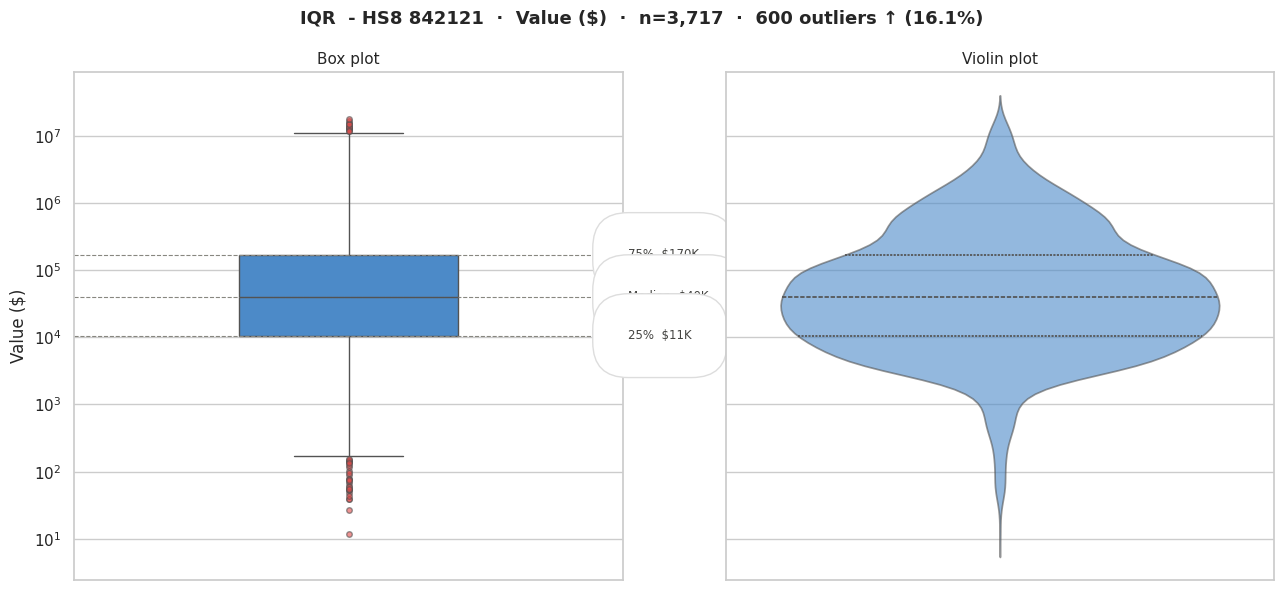

Outliers (> hi_fence): 600
Outliers (< lo_fence): 0
hi_fence: $410K
lo_fence: $-229,242


In [33]:
df_comm = dataset[dataset['HS6'] == commodity_code]['Value ($)'].dropna()
df_comm = df_comm[df_comm > 0]

# ── stats ──────────────────────────────────────────────────────────────────
n      = len(df_comm) # observations

# Quartis and Median
median = df_comm.median()
p25    = df_comm.quantile(0.25)
p75    = df_comm.quantile(0.75)


iqr    = p75 - p25
lo_fence = p25 - 1.5 * iqr
hi_fence = p75 + 1.5 * iqr
n_out_low  = (df_comm < lo_fence).sum()
n_out_high = (df_comm > hi_fence).sum()
n_out      = n_out_low + n_out_high

def fmt(v):
    if v >= 1e6: return f'${v/1e6:.1f}M'
    if v >= 1e3: return f'${v/1e3:.0f}K'
    return f'${v:,.0f}'

# direção dos outliers
if n_out_low > 0 and n_out_high == 0:
    out_dir = 'outliers ↓'
elif n_out_high > 0 and n_out_low == 0:
    out_dir = 'outliers ↑'
else:
    out_dir = 'outliers -both ↕'

# ── figure ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
fig.suptitle(
    f'IQR  - HS8 {commodity_code}  ·  Value ($)  ·  n={n:,}  ·  '
    f'{n_out} {out_dir} ({n_out/n*100:.1f}%)',
    fontsize=13, fontweight='bold'
)

for ax in (ax1, ax2):
    ax.set_yscale('log')

# box plot
sns.boxplot(y=df_comm, ax=ax1, color='#378ADD', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='#E24B4A', markersize=4, alpha=0.6))
ax1.set_title('Box plot', fontsize=11)

# anotations
for label, val in [('75%', p75), ('Median', median), ('25%', p25)]:
    ax1.axhline(val, color='#888780', linewidth=0.8, linestyle='--')
    ax1.annotate(
        f'{label}  {fmt(val)}',
        xy=(1.01, val),
        xycoords=('axes fraction', 'data'),
        fontsize=8.5,
        color='#444441',
        va='center',
        bbox=dict(facecolor='white', edgecolor='#ddd', pad=3, boxstyle='round')
    )

# violin plot
sns.violinplot(y=df_comm, ax=ax2, color='#378ADD', alpha=0.6, inner='quartile')
ax2.set_title('Violin plot', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Outliers (> hi_fence): {n_out_high}")
print(f"Outliers (< lo_fence): {n_out_low}")
print(f"hi_fence: {fmt(hi_fence)}")
print(f"lo_fence: {fmt(lo_fence)}")